In [2]:
import numpy as np
import random 
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
import matplotlib.pyplot as plt

In [3]:
X_train = np.loadtxt('input.csv', delimiter=',')
Y_train = np.loadtxt('labels.csv', delimiter=',')

X_test = np.loadtxt('input_test.csv', delimiter=',')
Y_test = np.loadtxt('labels_test.csv', delimiter=',')


In [4]:
print(X_train)

[[ 37.  39.  25. ...  58.  54.  29.]
 [131. 128. 135. ...  71.  96.  74.]
 [ 80.  92.  88. ... 124. 119.  99.]
 ...
 [231. 226. 230. ...  62.  65.  72.]
 [ 61.  61.  63. ... 135. 123. 123.]
 [ 64.  31.  12. ...  61.  49.  35.]]


In [5]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)
X_train = X_train/255
X_test = X_test/255

In [6]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)

Shape of X_train:  (2000, 100, 100, 3)
Shape of Y_train:  (2000, 1)
Shape of X_test:  (400, 100, 100, 3)
Shape of Y_test:  (400, 1)


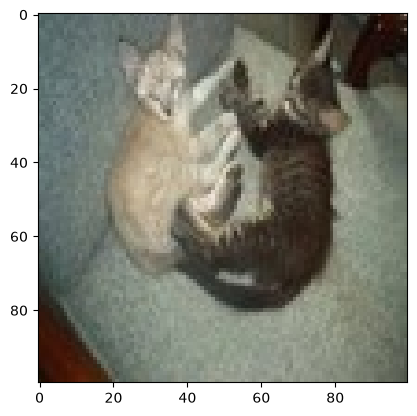

In [7]:
idx = random.randint(0, len(X_train)) 
plt.imshow(X_train[idx, :])
plt.show()

In [8]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation='sigmoid'))

/opt/anaconda3/envs/tensorflow/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [10]:
history = model.fit(
    X_train,
    Y_train,
    epochs=30,
    batch_size=64,
    validation_data=(X_test, Y_test)
)

Epoch 1/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step - accuracy: 0.5000 - loss: 0.6951 - val_accuracy: 0.5825 - val_loss: 0.6893
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 148ms/step - accuracy: 0.5370 - loss: 0.6899 - val_accuracy: 0.5675 - val_loss: 0.6672
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.5510 - loss: 0.6765 - val_accuracy: 0.6400 - val_loss: 0.6560
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 151ms/step - accuracy: 0.6300 - loss: 0.6371 - val_accuracy: 0.6500 - val_loss: 0.6168
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.6435 - loss: 0.6309 - val_accuracy: 0.6750 - val_loss: 0.6161
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.6785 - loss: 0.5953 - val_accuracy: 0.6250 - val_loss: 0.6385
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.6990 - loss: 0.5830 - val_accuracy: 0.6600 - val_loss: 0.6040
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 154ms/step - accuracy: 0.7195 - loss: 0.5584 - val_accuracy: 0.

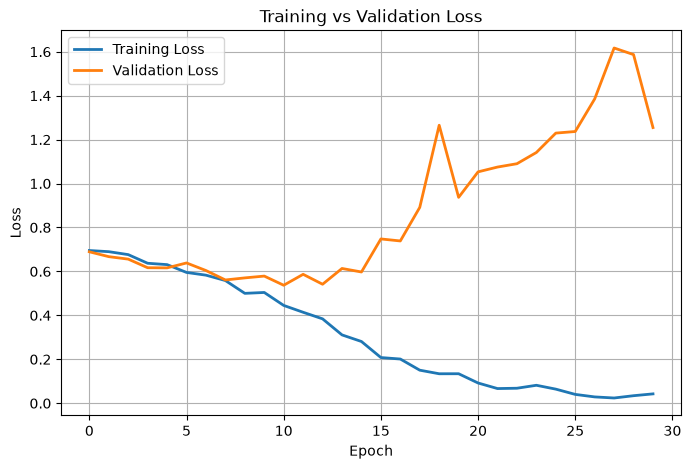

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

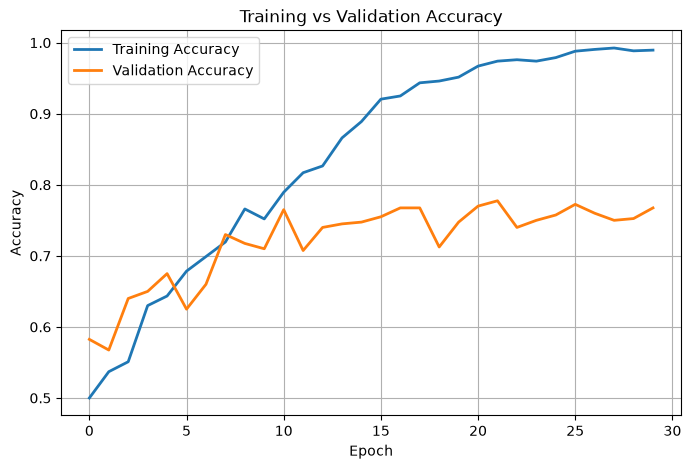

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [13]:
loss, accuracy = model.evaluate(X_test, Y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7675 - loss: 1.2548
Test Loss: 1.2548
Test Accuracy: 76.75%


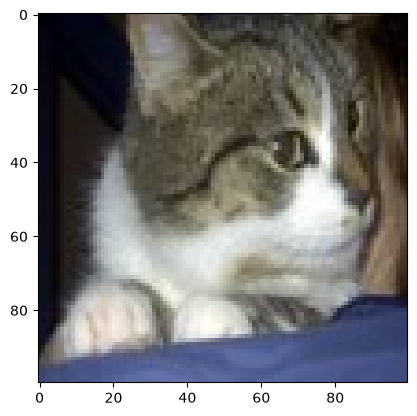

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Our model says it is a: cat


In [33]:
idx2 = random.randint(0, len(Y_test))

plt.imshow(X_test[idx2, :])
plt.show()
y_pred = model.predict(X_test[idx2, :].reshape(1, 100, 100, 3))

y_pred = y_pred > 0.5

if (y_pred == 0):
    pred = "dog"
else:
    pred = "cat"

print("Our model says it is a:", pred)